# 점수기준과오류비교

박스 필터링부터 평가·요구 조건에 맞는 기준 선택까지 하나의 처리 흐름으로 구현합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [1]:
from pathlib import Path
import os, sys, json, time

ROOT = Path(r"C:\Users\User\.ngv_day4_2026\pm\1b2d65c48c7e")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
from ultralytics import YOLO
dataset=ROOT/'dataset_group20_seed42'
if not (dataset/'annotations.json').exists():
    from speed_project import prepare_data
    dataset,_=prepare_data(seed=42)
records=json.loads((dataset/'annotations.json').read_text(encoding='utf-8'))
run=ROOT/'runs/verified'
WEIGHTS=run/'weights/best.pt'


## 앞에서 구현한 기능 재사용 · 제공 코드
IoU·일대일 매칭은 완성 코드로 제공합니다. 지표는 매칭 결과의 TP·FP·FN으로 계산합니다.
`entries`: 사진별 image/gt/boxes/scores 목록. 박스는 원본 픽셀 xyxy 좌표입니다.


In [2]:
def iou(a,b):
    iw=max(0,min(a[2],b[2])-max(a[0],b[0]))
    ih=max(0,min(a[3],b[3])-max(a[1],b[1]))
    intersection=iw*ih
    area_a=max(0,a[2]-a[0])*max(0,a[3]-a[1])
    area_b=max(0,b[2]-b[0])*max(0,b[3]-b[1])
    union=area_a+area_b-intersection
    return intersection/union if union>0 else 0.
def match(entry,conf=.25,iou_threshold=.5):
    scores=np.asarray(entry['scores'])
    order=[int(i) for i in np.argsort(-scores,kind='stable') if scores[i]>=conf]
    used=set();hits=[]
    for i in order:
        remaining=[j for j in range(len(entry['gt'])) if j not in used]
        j=max(remaining,key=lambda j:iou(entry['boxes'][i],entry['gt'][j])) if remaining else None
        ok=j is not None and iou(entry['boxes'][i],entry['gt'][j])>=iou_threshold
        if ok:used.add(j)
        hits.append(bool(ok))
    return order,hits,[j for j in range(len(entry['gt'])) if j not in used]
def metrics(entries,conf=.25):
    tp=fp=fn=0
    for e in entries:
        order,hits,miss=match(e,conf)
        tp+=sum(hits);fp+=len(hits)-sum(hits);fn+=len(miss)
    p=tp/max(tp+fp,1);r=tp/max(tp+fn,1)
    return dict(TP=tp,FP=fp,FN=fn,precision=p,recall=r,F1=2*p*r/max(p+r,1e-12))
def collect(weights,dataset,imgsz=320,split='val',limit=None):
    model=YOLO(str(weights))
    records=json.loads((dataset/'annotations.json').read_text())
    paths=sorted((dataset/'images'/split).glob('*.png'))
    if limit is not None:paths=paths[:limit]
    if not paths:raise ValueError('평가 이미지가 없습니다.')
    model.predict(str(paths[0]),imgsz=imgsz,device='cpu',conf=.001,iou=.7,verbose=False)
    entries=[];times=[]
    for p in paths:
        start=time.perf_counter()
        r=model.predict(str(p),imgsz=imgsz,device='cpu',conf=.001,iou=.7,verbose=False)[0]
        times.append((time.perf_counter()-start)*1000)
        entries.append({'image':p.name,'gt':records[p.name]['boxes'],'boxes':r.boxes.xyxy.tolist(),'scores':r.boxes.conf.tolist()})
    return entries,{'mean_ms':float(np.mean(times)),'n':len(paths),'imgsz':imgsz,'split':split}

def draw_entry(entry, selected=None, title='예측'):
    image=Image.open(dataset/'images/val'/entry['image']).convert('RGB')
    draw=ImageDraw.Draw(image)
    for box in entry['gt']: draw.rectangle(box,outline='cyan',width=3)
    selected=range(len(entry['boxes'])) if selected is None else selected
    for i in selected: draw.rectangle(entry['boxes'][i],outline='red',width=2)
    plt.figure(figsize=(5,5));plt.imshow(image);plt.axis('off');plt.title(title+' / 청록: 정답, 빨강: 예측');plt.show()


## ✏️ B05 · 점수 기준 탐색 파이프라인 구현

각 점수 기준으로 모든 사진의 박스·점수를 함께 필터링하고 `metrics(filtered,0.)`로 평가하세요. 원본 entries와 gt는 유지합니다.
반환: `(rows, selected)`. 각 행은 `threshold`와 지표입니다.
선택: 목표 재현율 이상인 후보 중 정밀도가 가장 높은 행. 동률은 재현율로 비교하며 후보가 없으면 None입니다.

### 사용할 수 있는 API
사전 복사 `{**entry, "boxes":새목록, "scores":새목록}`, 리스트 `.append`, 비교·반복문.
`max(rows,key=lambda r:(r["a"],r["b"]))`는 a, 동률이면 b를 기준으로 선택합니다.
지표 함수의 반환 키: TP, FP, FN, precision, recall, F1.


### 처리 단계 힌트
1. 점수 기준 하나를 고릅니다.
2. 사진마다 유지할 예측 번호를 구합니다.
3. 같은 번호로 박스와 점수를 함께 고르고 평가합니다.
4. 모든 기준의 결과 중 목표 재현율을 만족하는 행을 선택합니다.

**작은 예시** · 점수가 `[0.2,0.8]`, 기준이 `0.5`이면 두 번째 박스와 점수 `0.8`을 함께 남깁니다. 정답 박스 목록은 유지합니다.


In [5]:
# ===== 실습 B05 시작 =====

def threshold_report(entries, thresholds, min_recall):
    rows = []
    
    for threshold in thresholds:
        filtered = []
        
        for e in entries:
            # 설정한 임계값(threshold) 이상인 스코어의 인덱스 추출
            ids = [i for i, s in enumerate(e['scores']) if s >= threshold]
            
            # 해당 인덱스의 boxes와 scores만 필터링하여 저장
            filtered.append({
                **e, 
                'boxes': [e['boxes'][i] for i in ids], 
                'scores': [e['scores'][i] for i in ids]
            })
        
        # 메트릭 계산 (metrics 함수가 외부에서 정의되어 있다고 가정)
        # TODO: 실제 환경에 맞게 metrics 함수의 인자(예: ground_truth)를 채워주세요.
        metric_results = metrics(filtered) 
        
        rows.append({
            'threshold': threshold, 
            **metric_results
        })
    
    # 최소 재현율(min_recall) 조건을 만족하는 행들만 필터링
    eligible = [r for r in rows if r['recall'] >= min_recall]
    
    # 조건 만족 가용 행 중 정밀도(precision) 우선, 그다음 재현율(recall)이 가장 높은 행 선택
    selected = max(eligible, key=lambda r: (r['precision'], r['recall'])) if eligible else None
    
    return rows, selected

    #raise NotImplementedError('B05: 필터·평가·조건 선택 연결')

# ===== 실습 B05 끝 =====


**B05 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [6]:
import copy
toy=[{'image':'a','gt':[[0,0,10,10]],'boxes':[[0,0,10,10],[20,20,30,30]],'scores':[.8,.4]}]
original=copy.deepcopy(toy);rows,selected=threshold_report(toy,[.2,.6,.9],1.)
assert toy==original,'B05: 원본을 변경하지 마세요.'
assert [r['threshold'] for r in rows]==[.2,.6,.9]
for row in rows:
    expected=metrics(toy,row['threshold'])
    assert all(np.isclose(row[k],expected[k]) for k in expected),'B05: 점수·박스 연결과 평가 기준을 확인하세요.'
assert selected['threshold']==.6
assert threshold_report(toy,[.9],1.)[1] is None
assert threshold_report(toy,[],.9)==([],None)
tie=[{'image':'a','gt':[[0,0,10,10],[20,20,30,30]],'boxes':[[0,0,10,10],[20,20,30,30]],'scores':[.8,.4]}]
assert threshold_report(tie,[.6,.2],.4)[1]['threshold']==.2,'B05: 정밀도 동률이면 재현율로 선택하세요.'
print('B05 통과: 원본 보존·필터·평가·조건 선택·후보 없음')


B05 통과: 원본 보존·필터·평가·조건 선택·후보 없음


## 실제 기준 선택과 오류 비교 · 제공 코드
모델·사진·NMS는 고정합니다. 점수 기준과 목표 재현율을 변경해 결과를 확인합니다.


{'threshold': 0.15, 'TP': 102, 'FP': 11, 'FN': 6, 'precision': 0.9026548672566371, 'recall': 0.9444444444444444, 'F1': 0.9230769230769231}
{'threshold': 0.4, 'TP': 102, 'FP': 5, 'FN': 6, 'precision': 0.9532710280373832, 'recall': 0.9444444444444444, 'F1': 0.9488372093023255}
{'threshold': 0.7, 'TP': 99, 'FP': 2, 'FN': 9, 'precision': 0.9801980198019802, 'recall': 0.9166666666666666, 'F1': 0.9473684210526315}
목표 재현율: 0.93 선택 결과: {'threshold': 0.4, 'TP': 102, 'FP': 5, 'FN': 6, 'precision': 0.9532710280373832, 'recall': 0.9444444444444444, 'F1': 0.9488372093023255}


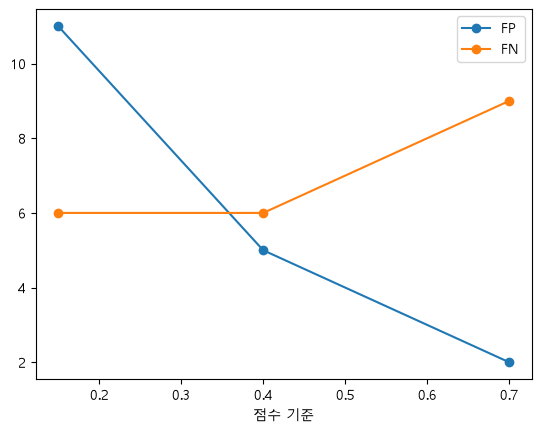

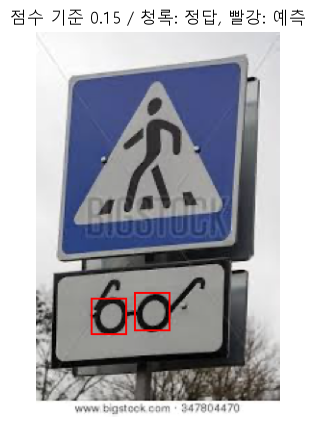

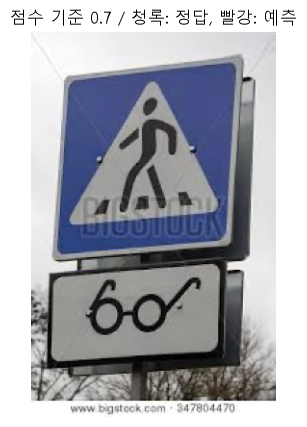

In [7]:
entries,_=collect(WEIGHTS,dataset,imgsz=320,split='val')
THRESHOLDS=[.15,.4,.7]
MIN_RECALL=.93
rows,selected=threshold_report(entries,THRESHOLDS,MIN_RECALL)
for row in rows:print(row)
print('목표 재현율:',MIN_RECALL,'선택 결과:',selected)
plt.plot(THRESHOLDS,[r['FP'] for r in rows],'o-',label='FP');plt.plot(THRESHOLDS,[r['FN'] for r in rows],'o-',label='FN');plt.xlabel('점수 기준');plt.legend();plt.show()
different=next((e for e in entries if sum(s>=THRESHOLDS[0] for s in e['scores'])!=sum(s>=THRESHOLDS[-1] for s in e['scores'])),None)
if different:
    for threshold in [THRESHOLDS[0],THRESHOLDS[-1]]:draw_entry(different,[i for i,s in enumerate(different['scores']) if s>=threshold],f'점수 기준 {threshold}')
